In [1]:
pip list | grep torch

torch                                    2.10.0+cu128
torchao                                  0.10.0
torchaudio                               2.10.0+cu128
torchcodec                               0.10.0+cu128
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.25.0+cu128


In [2]:
pip list | grep matplotlib

matplotlib                               3.10.0
matplotlib-inline                        0.2.1
matplotlib-venn                          1.1.2


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    './data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.27MB/s]


In [9]:
latent_dim = 20

In [5]:



class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)

        # mean and log variance
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [6]:
def loss_function(recon_x, x, mu, logvar):

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

    KL = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KL

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 100

for epoch in range(epochs):

    total_loss = 0

    for data, _ in train_loader:

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(data)

        loss = loss_function(recon, data, mu, logvar)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss / len(train_loader.dataset))

Epoch: 0 Loss: 163.59511388346354
Epoch: 1 Loss: 121.22833492838542
Epoch: 2 Loss: 114.48441363932292
Epoch: 3 Loss: 111.55181791992187
Epoch: 4 Loss: 109.85939156901041
Epoch: 5 Loss: 108.68403079427084
Epoch: 6 Loss: 107.88362104492188
Epoch: 7 Loss: 107.23381782226562
Epoch: 8 Loss: 106.76468893229166
Epoch: 9 Loss: 106.35963821614584
Epoch: 10 Loss: 105.96522752278646
Epoch: 11 Loss: 105.64212830403646
Epoch: 12 Loss: 105.41469510091146
Epoch: 13 Loss: 105.19205335286458
Epoch: 14 Loss: 104.9868505045573
Epoch: 15 Loss: 104.69842337239584
Epoch: 16 Loss: 104.61206902669271
Epoch: 17 Loss: 104.41308466796875
Epoch: 18 Loss: 104.24852143554688
Epoch: 19 Loss: 104.12065320638021
Epoch: 20 Loss: 103.94915634765626
Epoch: 21 Loss: 103.82687931315104
Epoch: 22 Loss: 103.73435789388022
Epoch: 23 Loss: 103.63971243489583
Epoch: 24 Loss: 103.50131393229167
Epoch: 25 Loss: 103.4137525390625
Epoch: 26 Loss: 103.29177734375
Epoch: 27 Loss: 103.19310738932292
Epoch: 28 Loss: 103.11390307617188


**Latent Interpolation**

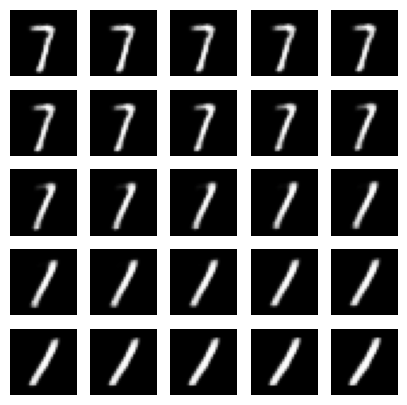

In [44]:
import matplotlib.pyplot as plt

model.eval()

data_iter = iter(train_loader)
images, _ = next(data_iter)

x1 = images[0].view(1,784).to(device)
x2 = images[1].view(1,784).to(device)

alphas = torch.linspace(0,1,25)

fig, axs = plt.subplots(5,5,figsize=(5,5))

with torch.no_grad():
    mu1, logvar1 = model.encode(x1)
    z1 = model.reparameterize(mu1, logvar1)

    mu2, logvar2 = model.encode(x2)
    z2 = model.reparameterize(mu2, logvar2)

    for i,a in enumerate(alphas):

        z = (1-a)*z1 + a*z2

        img = model.decode(z).cpu().view(28,28)

        axs.flatten()[i].imshow(img, cmap='gray')
        axs.flatten()[i].axis('off')

plt.show()

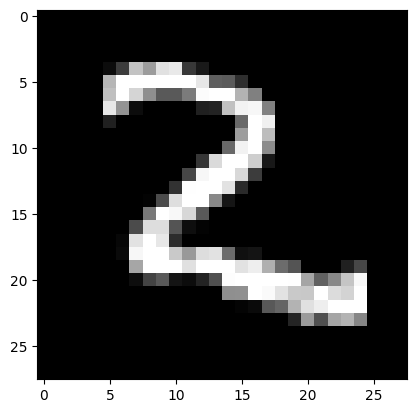

In [31]:
import cv2
plt.imshow(images[100].cpu().view(28, 28), cmap='gray')

**Sampling from Pior**

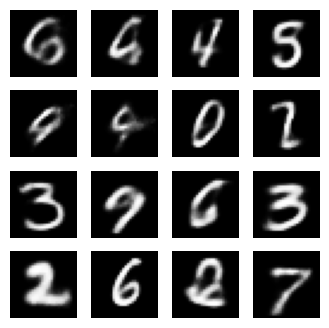

In [14]:
z = torch.randn(16, latent_dim).to(device)

with torch.no_grad():

    samples = model.decode(z).cpu()

fig, axs = plt.subplots(4,4,figsize=(4,4))

for i, ax in enumerate(axs.flatten()):

    img = samples[i].view(28,28)

    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.show()

In [49]:
z

tensor([[ 0.3384,  1.9713,  0.3938,  0.1560, -1.7003, -0.2180, -1.4979, -0.5730,
          0.8150, -0.5809, -0.3539, -0.8847, -1.3359,  1.7333,  3.0356, -0.3834,
          0.1573, -0.0804,  0.6805,  1.8784]], device='cuda:0')